In [2]:
import requests
import time
import random
import sqlite3
import re

# --- Brand list ---
TARGET_BRANDS = [
    'skoda', 'volkswagen', 'bmw', 'audi', 'mercedes-benz', 
    'ford', 'hyundai', 'kia', 'toyota', 'renault', 
    'peugeot', 'seat', 'opel', 'citroen', 'fiat', 
    'mazda', 'honda', 'nissan', 'volvo', 'subaru'
]

DB_NAME = "cars.db"

# --- 1. Function for parsing power ---
def parse_power(text):
    if not text: return None
    # Looking for "85 kW", "110kw", "150 KW"
    match = re.search(r'(\d+)\s*[kK][wW]', str(text))
    if match:
        return int(match.group(1))
    return None

# --- 2. Function for initializing the database ---
def init_db():
    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS cars (
            id INTEGER PRIMARY KEY,
            brand TEXT,
            model_name TEXT,
            details TEXT,  
            price INTEGER,
            year INTEGER,
            mileage INTEGER,
            fuel TEXT,
            gearbox TEXT,
            power INTEGER,
            url TEXT,
            parsed_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
        )
    ''')
    conn.commit()
    return conn

# Connect to the database and create the table if it doesn't exist
conn = init_db()
cursor = conn.cursor()

url = "https://www.sauto.cz/api/v1/items/search"
headers = {
    'accept': 'application/json',
    'content-type': 'application/json',
    'user-agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
}

print(f"🚀 LAUNCH V2: Collecting data with extended parameters...")

total_saved = 0

for brand in TARGET_BRANDS:
    print(f"\n🚘 --- Brand: {brand.upper()} ---")
    page = 0
    max_pages = 50 
    
    while page < max_pages:
        params = {
            'limit': 20,
            'offset': page * 20,
            'category_id': 838,
            'condition_seo': 'nove,ojete,predvadeci',
            'manufacturer_model_seo': brand,
        }
        
        print(f"   ⏳ {brand}: page {page + 1} | In DB: {total_saved}...", end="\r", flush=True)
        
        try:
            response = requests.get(url, headers=headers, params=params, timeout=5)
            
            if response.status_code == 200:
                data = response.json()
                results = data.get("results", [])
                
                if not results:
                    break
                
                for car in results:
                    car_id = car.get("id")
                    name = car.get("name")
                    
                    # --- NEW FIELD ---
                    # Taking detailed description ("Selection 1.5 TSI...")
                    details = car.get("additional_model_name") 
                    
                    price = car.get("price")
                    
                    date_str = car.get("manufacturing_date") or car.get("in_operation_date") or ""
                    year = int(date_str[:4]) if date_str and date_str[:4].isdigit() else None
                    
                    mileage = car.get("tachometer")
                    fuel = car.get("fuel_cb", {}).get("name")
                    gearbox = car.get("gearbox_cb", {}).get("name")
                    
                    # --- IMPROVED POWER SEARCH ---
                    # 1. First, try to get the ready-made power field
                    power = car.get("power")
                    # 2. If empty, look in the detailed description (usually most reliable)
                    if not power:
                        power = parse_power(details)
                    # 3. If still empty, look in the regular name
                    if not power:
                        power = parse_power(name)
                    
                    seo_url = car.get("seo", {}).get("url")
                    full_url = seo_url if seo_url else f"https://www.sauto.cz/osobni/detail/{brand}/car/{car_id}"

                    # Saving the new structure
                    cursor.execute('''
                        INSERT OR IGNORE INTO cars 
                        (id, brand, model_name, details, price, year, mileage, fuel, gearbox, power, url)
                        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
                    ''', (car_id, brand, name, details, price, year, mileage, fuel, gearbox, power, full_url))
                
                conn.commit()
                total_saved += len(results)
                page += 1
                
            else:
                break
                
        except Exception:
            break
            
        time.sleep(random.uniform(0.3, 0.6))

conn.close()
print(f"\n\n🏁 DONE! Updated database collected.")

🚀 LAUNCH V2: Collecting data with extended parameters...

🚘 --- Brand: SKODA ---
   ⏳ skoda: page 50 | In DB: 980...
🚘 --- Brand: VOLKSWAGEN ---
   ⏳ volkswagen: page 50 | In DB: 1980...
🚘 --- Brand: BMW ---
   ⏳ bmw: page 50 | In DB: 2980...
🚘 --- Brand: AUDI ---
   ⏳ audi: page 50 | In DB: 3980...
🚘 --- Brand: MERCEDES-BENZ ---
   ⏳ mercedes-benz: page 50 | In DB: 4980...
🚘 --- Brand: FORD ---
   ⏳ ford: page 50 | In DB: 5980...
🚘 --- Brand: HYUNDAI ---
   ⏳ hyundai: page 50 | In DB: 6980...
🚘 --- Brand: KIA ---
   ⏳ kia: page 50 | In DB: 7980...
🚘 --- Brand: TOYOTA ---
   ⏳ toyota: page 50 | In DB: 8980...
🚘 --- Brand: RENAULT ---
   ⏳ renault: page 50 | In DB: 9980...
🚘 --- Brand: PEUGEOT ---
   ⏳ peugeot: page 50 | In DB: 10980...
🚘 --- Brand: SEAT ---
   ⏳ seat: page 50 | In DB: 11980...
🚘 --- Brand: OPEL ---
   ⏳ opel: page 50 | In DB: 12980...
🚘 --- Brand: CITROEN ---
   ⏳ citroen: page 50 | In DB: 13980...
🚘 --- Brand: FIAT ---
   ⏳ fiat: page 50 | In DB: 14980...
🚘 --- Brand:

In [3]:
import pandas as pd
import sqlite3
import numpy as np

# 1. Connection
conn = sqlite3.connect("cars.db")
df = pd.read_sql("SELECT * FROM cars", conn)
conn.close()

print(f"📥 Raw data records: {len(df)}")

# --- FILTERING ---
# Removing price outliers (junk below 30k and exclusives above 5M)
df = df[(df['price'] > 30000) & (df['price'] < 5000000)]

# Removing duplicates (in case IDs were repeated)
df = df.drop_duplicates(subset=['id'])

# --- DROPPING UNNECESSARY COLUMNS ---
# id, url, parsed_at - these don't affect the price physics
cols_to_drop = ['id', 'url', 'parsed_at', 'model_name']
df = df.drop(columns=cols_to_drop, errors='ignore')

# --- MISSING DATA HANDLING (Imputation) ---
# For text: replace NaN with "Unknown"
text_cols = ['brand', 'details', 'fuel', 'gearbox']
for col in text_cols:
    df[col] = df[col].fillna("Unknown")

# For numbers: FIXING POWER (power) 🛠️
# 1. Convert to numeric, turn all errors (like text) into NaN
df['power'] = pd.to_numeric(df['power'], errors='coerce')

# 2. Remove anomalies: everything less than 20 kW or more than 600 kW becomes NaN
df.loc[(df['power'] < 20) | (df['power'] > 600), 'power'] = np.nan

# 3. Smart filling: use median by brand and specific trim (details)
df['power'] = df['power'].fillna(df.groupby(['brand', 'details'])['power'].transform('median'))

# 4. If the trim is rare and still empty, use the median by brand only
df['power'] = df['power'].fillna(df.groupby('brand')['power'].transform('median'))

# 5. If any "orphans" remain, fill with the overall database median
df['power'] = df['power'].fillna(df['power'].median())

# --- SAVING ---
output_file = "cars_ready.csv"
df.to_csv(output_file, index=False)

print(f"🧹 After cleaning: {len(df)}")
print(f"💾 Data saved to '{output_file}'")
print(df.head(3))

📥 Raw data records: 27897
🧹 After cleaning: 27551
💾 Data saved to 'cars_ready.csv'
     brand                        details  price  year  mileage   fuel  \
0  renault      Serviska cebia VIN MAILEM  79000  2010   239000  Nafta   
1   subaru  2,0 Active Combi, nová spojka  72000  2009   189704  Nafta   
2   nissan            1.9 dCi First Class  40000  2003   207000  Nafta   

    gearbox  power  
0  Manuální   82.0  
1  Manuální  110.0  
2  Manuální   96.0  


📂 Data loaded: 27551 rows


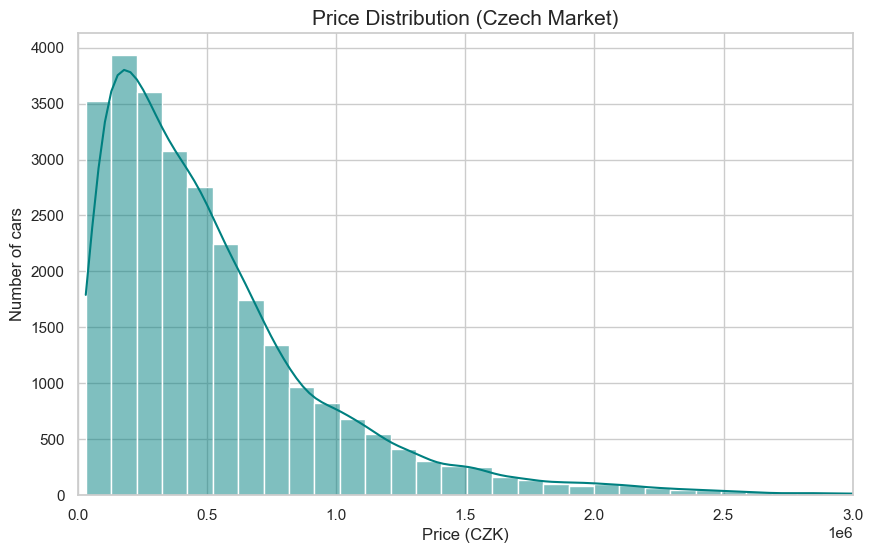

/var/folders/nf/_plpz1p57pv31n9md8s7b1s40000gn/T/ipykernel_14547/3628502041.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='brand', y='price', data=df_top, palette='viridis', order=top_brands)


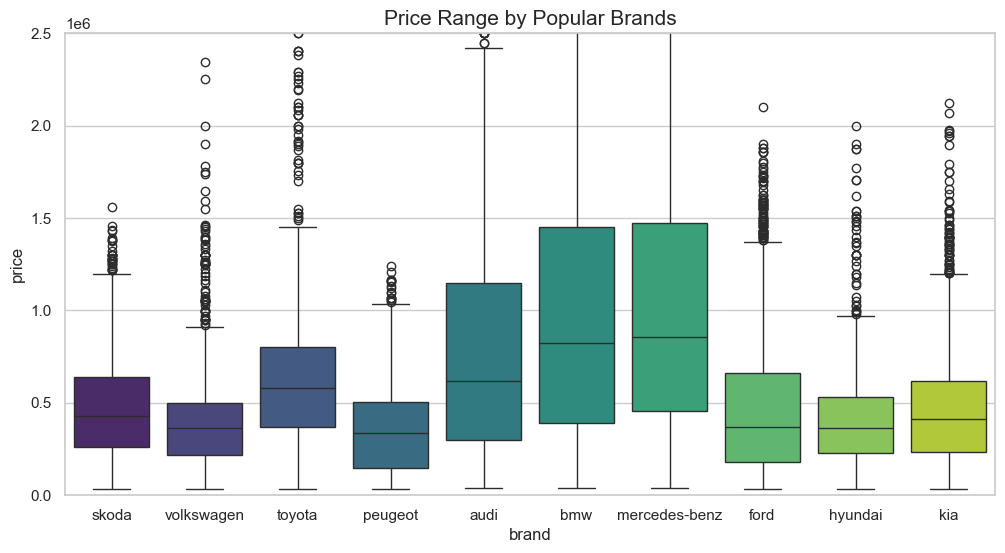

/var/folders/nf/_plpz1p57pv31n9md8s7b1s40000gn/T/ipykernel_14547/3628502041.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='body_type_guess', y='price', data=df_body, palette='coolwarm')


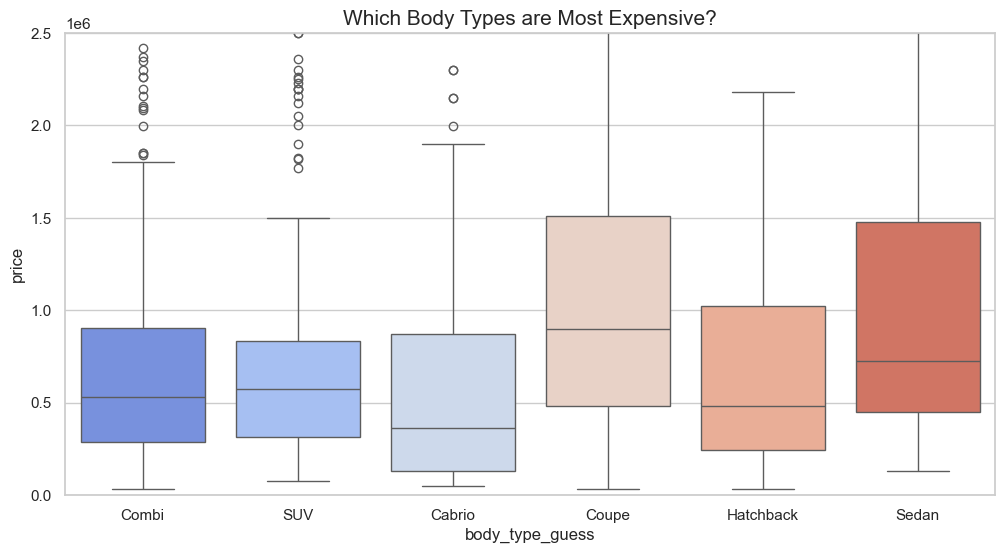

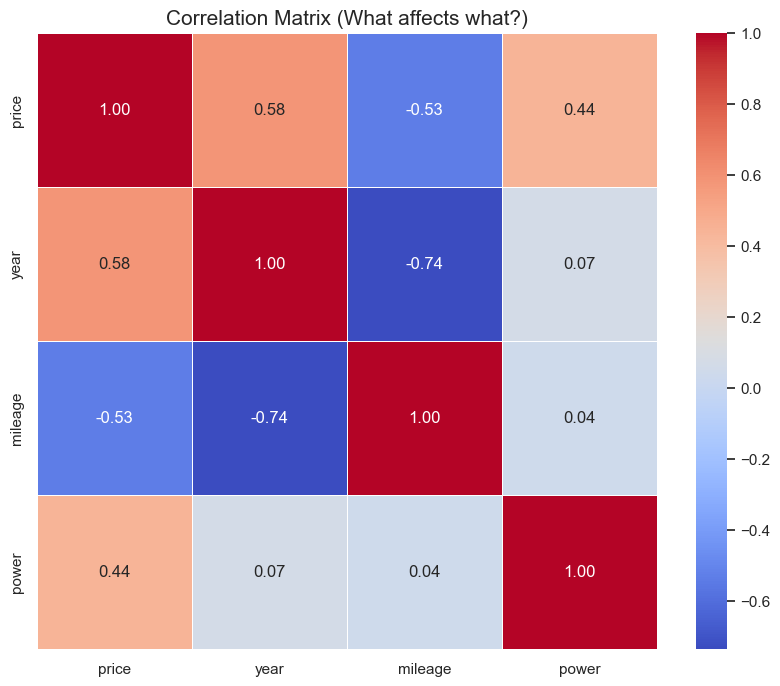

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Plot style settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Load data
df = pd.read_csv("cars_ready.csv")
print(f"📂 Data loaded: {len(df)} rows")

# --- HACK: Extract Body Type from text for the chart ---
def guess_body_type(text):
    t = str(text).lower()
    if any(x in t for x in ['combi', 'kombi', 'avant', 'variant', 'touring', 'sw']): return 'Combi'
    if any(x in t for x in ['suv', 'cross', 'tiguan', 'kodiaq', 'touareg', 'x5', 'q7', 'cr-v']): return 'SUV'
    if any(x in t for x in ['sedan', 'limuzina', 'limousin']): return 'Sedan'
    if any(x in t for x in ['hatchback', 'fabia', 'golf', 'polo']): return 'Hatchback'
    if any(x in t for x in ['coupe', 'coupé']): return 'Coupe'
    if any(x in t for x in ['cabrio', 'kabrio']): return 'Cabrio'
    return 'Other'

df['body_type_guess'] = df['details'].apply(guess_body_type)

# --- PLOT 1: Histogram (How are prices distributed?) ---
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True, color='teal')
plt.title('Price Distribution (Czech Market)', fontsize=15)
plt.xlabel('Price (CZK)')
plt.ylabel('Number of cars')
plt.xlim(0, 3000000) # Cut the tail > 3M for better visualization
plt.show()

# --- PLOT 2: Boxplot (Price vs Brand) ---
# Taking only Top-10 brands to avoid clutter
top_brands = df['brand'].value_counts().head(10).index
df_top = df[df['brand'].isin(top_brands)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='brand', y='price', data=df_top, palette='viridis', order=top_brands)
plt.title('Price Range by Popular Brands', fontsize=15)
plt.ylim(0, 2500000)
plt.show()

# --- PLOT 3: Boxplot (Price vs Body Type) ---
plt.figure(figsize=(12, 6))
# Remove "Other" category to keep it clean
df_body = df[df['body_type_guess'] != 'Other']
sns.boxplot(x='body_type_guess', y='price', data=df_body, palette='coolwarm')
plt.title('Which Body Types are Most Expensive?', fontsize=15)
plt.ylim(0, 2500000)
plt.show()

# --- PLOT 4: Heatmap (What correlates with what?) ---
# Calculating correlation for numeric values only
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix (What affects what?)', fontsize=15)
plt.show()

In [6]:
# Looking at the overall statistics: are there any anomalous maxima/minima
print(df['power'].describe())

# Checking how many zeros or empty strings we have in total
print("Empty values (NaN):", df['power'].isna().sum())
print("Values equal to zero:", (df['power'] == 0).sum())

count    27551.000000
mean       112.548093
std         36.262890
min         22.000000
25%         92.000000
50%        107.000000
75%        130.000000
max        500.000000
Name: power, dtype: float64
Empty values (NaN): 0
Values equal to zero: 0


--- 📊 Power Column Statistics ---


count    27551.000000
mean       112.548093
std         36.262890
min         22.000000
25%         92.000000
50%        107.000000
75%        130.000000
max        500.000000
Name: power, dtype: float64


--- 🏎️ Top 5 cars with MAXIMUM power (looking for top outliers) ---


,price,year,mileage,power
22233,1749900,2026,1,500.0
22235,1894900,2026,1,500.0
26291,2899000,2023,33469,480.0
4099,1771645,2025,5,478.0
2650,1659900,2025,0,478.0



--- 🐢 Top 5 cars with MINIMUM power (looking for zeros or bottom junk) ---


,price,year,mileage,power
15092,1209999,2023,69986,22.0
15143,1270500,2023,41400,22.0
15064,1270500,2022,72800,22.0
6507,249999,2017,71777,22.0
25257,299000,2022,31518,24.0


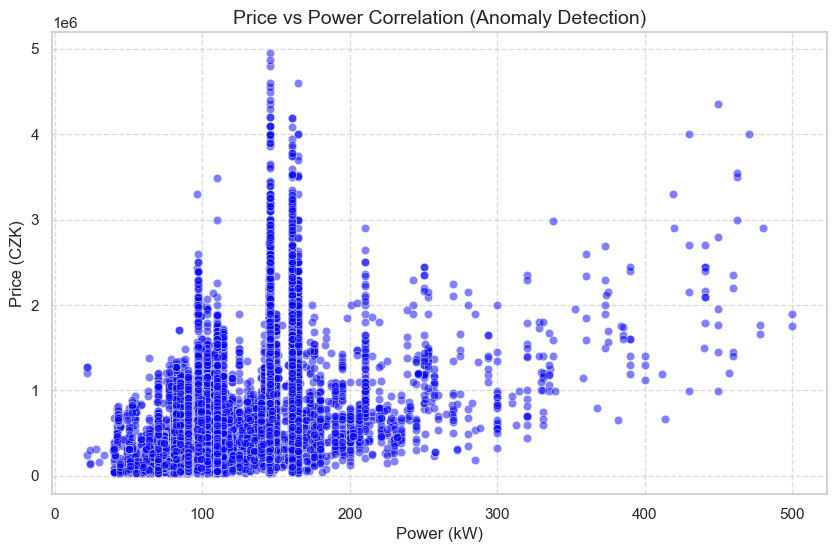

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (if your cleaned data is in a different file, change the name)
df = pd.read_csv('cars_ready.csv')

# If your dataframe is not named df, just change df to your variable name! 😉

print("--- 📊 Power Column Statistics ---")
display(df['power'].describe())

print("\n--- 🏎️ Top 5 cars with MAXIMUM power (looking for top outliers) ---")
display(df[['price', 'year', 'mileage', 'power']].sort_values(by='power', ascending=False).head(5))

print("\n--- 🐢 Top 5 cars with MINIMUM power (looking for zeros or bottom junk) ---")
display(df[['price', 'year', 'mileage', 'power']].sort_values(by='power').head(5))

# Plotting the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='power', y='price', alpha=0.5, color='blue')
plt.title('Price vs Power Correlation (Anomaly Detection)', fontsize=14)
plt.xlabel('Power (kW)', fontsize=12)
plt.ylabel('Price (CZK)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

📥 1. Loading clean data...
🧠 2. Feature Engineering (Clusters, Age, Text Mining)...
📉 3. Preparing for training...
🚀 4. Initializing CatBoost (on 22040 cars)...
0:	learn: 0.8418103	test: 0.8463946	best: 0.8463946 (0)	total: 63ms	remaining: 1m 34s
100:	learn: 0.2967412	test: 0.3000476	best: 0.3000476 (100)	total: 583ms	remaining: 8.08s
200:	learn: 0.2803684	test: 0.2908225	best: 0.2908225 (200)	total: 1.07s	remaining: 6.89s
300:	learn: 0.2721458	test: 0.2875758	best: 0.2875758 (300)	total: 1.55s	remaining: 6.19s
400:	learn: 0.2662835	test: 0.2854775	best: 0.2854775 (400)	total: 2.03s	remaining: 5.56s
500:	learn: 0.2611650	test: 0.2837158	best: 0.2836859 (499)	total: 2.5s	remaining: 4.99s
600:	learn: 0.2571512	test: 0.2829513	best: 0.2829513 (600)	total: 2.97s	remaining: 4.45s
700:	learn: 0.2540370	test: 0.2826244	best: 0.2826050 (671)	total: 3.45s	remaining: 3.93s
800:	learn: 0.2509975	test: 0.2820539	best: 0.2820531 (798)	total: 3.93s	remaining: 3.43s
900:	learn: 0.2481452	test: 0.2817

/var/folders/nf/_plpz1p57pv31n9md8s7b1s40000gn/T/ipykernel_14547/3020287424.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importances", y="Feature Id", data=feat_imp, palette="magma", ax=axes[1])


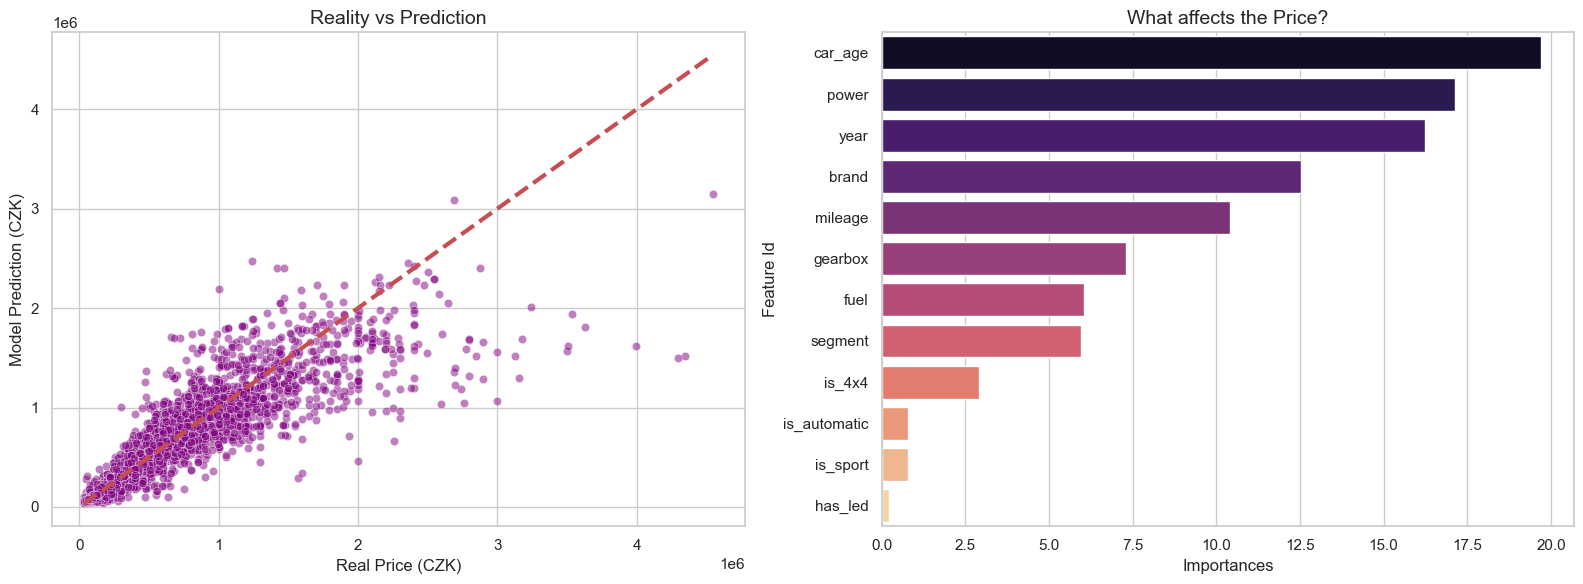

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

print("📥 1. Loading clean data...")
# Loading the already cured dataset! No extra power cleaning needed.
df = pd.read_csv('cars_ready.csv') 

print("🧠 2. Feature Engineering (Clusters, Age, Text Mining)...")
# Clustering
X_cluster = df[['year', 'mileage', 'power']].copy()
X_scaled = StandardScaler().fit_transform(X_cluster)
df['segment'] = KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(X_scaled).astype(str)

# Car Age
df['car_age'] = 2026 - df['year']

# Extracting gold from text!
df['details'] = df['details'].fillna("Unknown").astype(str)
details_lower = df['details'].str.lower()

df['is_4x4'] = details_lower.str.contains(r'4x4|awd|quattro|xdrive|4matic').astype(int)
df['is_automatic'] = details_lower.str.contains(r'automat|dsg|tiptronic|stronic').astype(int)
df['is_sport'] = details_lower.str.contains(r'rs|gti|m-packet|amg|sport|s-line').astype(int)
df['has_led'] = details_lower.str.contains(r'led|matrix|xenon').astype(int)


print("📉 3. Preparing for training...")
# Dropping text (we've already extracted everything useful from it)
X = df.drop(columns=['price', 'details']) 
y = df['price']

# Log-transforming the price! (Helps with skewed data)
y_log = np.log1p(y) 

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# Categorical features handling
cat_features = ['brand', 'fuel', 'gearbox', 'segment'] 
for col in cat_features:
    X_train[col] = X_train[col].fillna("Unknown").astype(str)
    X_test[col] = X_test[col].fillna("Unknown").astype(str)


print(f"🚀 4. Initializing CatBoost (on {len(X_train)} cars)...")
model = CatBoostRegressor(
    iterations=1500,    
    learning_rate=0.08, 
    depth=7,
    loss_function='RMSE',
    verbose=100,        
    random_seed=42
)

model.fit(
    X_train, y_train_log, 
    cat_features=cat_features,
    eval_set=(X_test, y_test_log),
    early_stopping_rounds=50
)
print("💾 Model saved in memory!")


print("📊 5. Calculating metrics and plotting...")
# Reverting log-prices back to real CZK
predictions_real = np.expm1(model.predict(X_test))
y_test_real = np.expm1(y_test_log)

r2 = r2_score(y_test_real, predictions_real)
mae = mean_absolute_error(y_test_real, predictions_real)

print("\n" + "="*45)
print(f"🏆 FINAL SUPER-RESULT:")
print(f"📊 Accuracy (R2 Score): {r2:.4f}") 
print(f"💰 Average Error (MAE): {mae:,.0f} CZK")
print("="*45)

# Plotting graphs
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(x=y_test_real, y=predictions_real, alpha=0.5, color='purple', ax=axes[0])
axes[0].plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'r--', lw=3)
axes[0].set_title('Reality vs Prediction', fontsize=14)
axes[0].set_xlabel('Real Price (CZK)')
axes[0].set_ylabel('Model Prediction (CZK)')

feat_imp = model.get_feature_importance(prettified=True).head(15)
sns.barplot(x="Importances", y="Feature Id", data=feat_imp, palette="magma", ax=axes[1])
axes[1].set_title('What affects the Price?', fontsize=14)

plt.tight_layout()
plt.show()